# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Objective:**
To analyze a Kaggle dataset of 426,000 used car records to identify the key factors that drive vehicle prices up or down.

**Deliverable:**
To translate these data-driven insights into actionable recommendations that will help a used car dealership optimize its inventory and improve sales.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Here are the steps of understanding the data:

**Data Understanding Workflow**

***Initial Inspection:*** Import the dataset and perform a high-level review of its structure, checking the total number of rows and columns, data types, and previewing the first and last few records.

***Data Description:*** Examine each specific column to identify its possible values and calculate basic descriptive statistics (like the minimum, maximum, and average values).

***Data Exploration:*** Analyze the distribution of the target variable (price) to see how car prices are spread out. Identify which variables are categorical (text-based) and explore their unique values.

***Data Quality Verification:*** Systematically check the dataset for flaws. This includes identifying missing (blank) values, locating extreme outliers in the price, and finding data quality issues like duplicates, inconsistencies, or structural errors to plan how they will be addressed in the next phase.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Load Data
df = pd.read_csv('data/vehicles.csv')
print(f"Original shape: {df.shape}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Original shape: (426880, 18)


***Interpretation:*** The dataset contains 426,000 rows and 18 columns. This indicates that we have a decent sized dataset which can be used to detemine the features influence used car prices.

***Step: Missing Data Visualization***

In this step generating a visual heatmap and prints out the exact percentage of missing information for every single column. This allows us to see how incomplete the dataset is and which features (like size or cylinders) need the most attention.

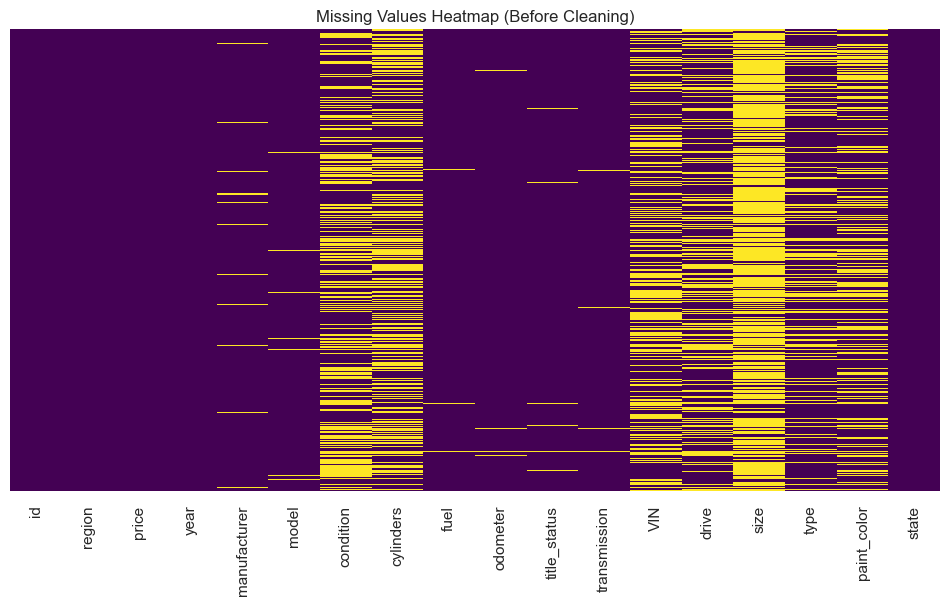

Missing Data Percentage:
 size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
dtype: float64


In [16]:
# Visual representation of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Before Cleaning)")
plt.savefig('images/missing_values_heatmap.png', bbox_inches='tight')
plt.show()

# Calculate percentage of missing data
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
print("Missing Data Percentage:\n", missing_pct[missing_pct > 0])

***Interpretation:***

Summary of the missing data results, categorized by severity to help guide your data cleaning strategy:

1. Critical Missing Data (Over 70%)

****size (71.77%)**** column is missing nearly three-quarters of its data. Attempting to fill in this much missing information would introduce heavy bias into your model. Therefore, it is recommended to completely drop this column from the dataset.

2. High to Moderate Missing Data (20% — 45%)

Columns: cylinders (41.6%), condition (40.8%), VIN (37.7%), drive (30.6%), paint_color (30.5%), and type (21.7%).

A significant chunk of data is missing on these columns. However, these columns may be important in determining the price of used cars. We cannot simply drop these rows either as that will result in losing almost half of your dataset. Therefore, we will use imputation and feature engineering.

For categorical text like condition or paint_color, fill the blanks with a placeholder like 'unknown'.

For cylinders or drive, fill blanks with the most frequent value (the mode).

For VIN, convert it to a binary feature (1 if they provided a VIN, 0 if they didn't) rather than trying to guess a unique string.

3. Minor Missing Data (Under 5%)

Columns: manufacturer (4.1%), title_status (1.9%), model (1.2%), odometer (1.0%), fuel (0.7%), transmission (0.6%), and year (0.2%). These columns are nearly complete. The missing values represent a very tiny fraction of the 426,000 total records.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

***Advanced Data Cleaning & Imputation***

- Completely removes columns that provide no value (id, size).

- Instead of deleting the Vehicle Identification Number (VIN) column, it turns it into a useful True/False column (has_VIN).

- Instead of deleting rows with missing data, it fills them in using statistics. It fills missing odometer readings with the median mileage, extracts engine numbers from text strings, and fills missing categorical data (like fuel or transmission) with the most frequent value (the mode).

In [17]:
clean_df = df.copy()

# Drop columns with larger % missing values.
# Dropping id and size columns as they have ~70% missing values
clean_df = clean_df.drop(columns=['id', 'size'])

# Since the exact VIN # is not directly valuable, transforming the VIN to a binary feature 'has_VIN'
clean_df['has_VIN'] = clean_df['VIN'].notna().astype(int)
clean_df = clean_df.drop(columns=['VIN'])  

# Advanced Imputation Strategies
# Filling missing Odometer with the median
clean_df['odometer'] = clean_df['odometer'].fillna(clean_df['odometer'].median())

# Making cylinders a numeric vaklue based on the value provided. Ex. '6 cylinders => 6 
# Clean and impute 'cylinders' (Extract number, fill missing with mode '6')
clean_df['cylinders'] = clean_df['cylinders'].str.extract('(\d+)').astype(float)
clean_df['cylinders'] = clean_df['cylinders'].fillna(6.0) 

# Categorical imputations using 'unknown' or the mode
clean_df['condition'] = clean_df['condition'].fillna('unknown')
clean_df['drive'] = clean_df['drive'].fillna(clean_df['drive'].mode()[0])
clean_df['transmission'] = clean_df['transmission'].fillna(clean_df['transmission'].mode()[0])
clean_df['fuel'] = clean_df['fuel'].fillna(clean_df['fuel'].mode()[0])
clean_df['type'] = clean_df['type'].fillna('other')
clean_df['paint_color'] = clean_df['paint_color'].fillna('unknown')

# Drop remaining rows where critical minor columns are missing
clean_df.dropna(subset=['year', 'manufacturer', 'model'], inplace=True)
clean_df['year'] = clean_df['year'].astype(int)

***Statistical Outlier Removal (IQR)***

This step is to prevent the extreme, unrealistic data points from misleading the models.

First, applying the basic common-sense filters: Cars must cost more than $500, Have miles > 0, and Be newer than 1990.

Then, applying Interquartile Range (IQR) to calculate a safe upper and lower boundary for car prices, mathematically stripping out extreme outliers rather than guessing a maximum price.

Finally, it applies a "log transformation" to the car prices to normalize the data, making it much easier for algorithms to learn from.

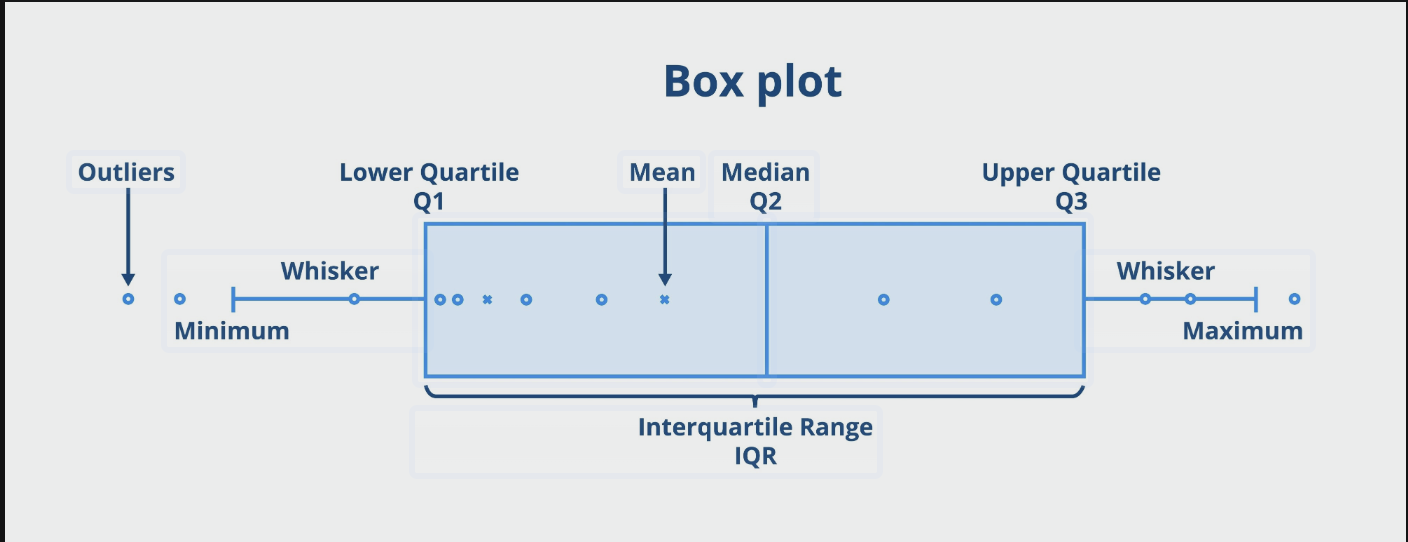

In [18]:
# Basic sane filters first
clean_df = clean_df[(clean_df['price'] > 500) & (clean_df['price'] < 600000)]
clean_df = clean_df[(clean_df['odometer'] > 0) & (clean_df['odometer'] < 999999)]
clean_df = clean_df[clean_df['year'] >= 1990] # Ignore antique cars

# IQR Filter for Price
Q1 = clean_df['price'].quantile(0.25)
Q3 = clean_df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply IQR filter
clean_df = clean_df[(clean_df['price'] >= lower_bound) & (clean_df['price'] <= upper_bound)]

# Log Transformation for target variable
clean_df['log_price'] = np.log1p(clean_df['price'])

print(f"Shape after IQR outlier removal: {clean_df.shape}")

Shape after IQR outlier removal: (347587, 17)


***Exploratory Data Analysis (EDA)***

With the cleaned data, this step visually explores the relationships within it to uncover business insights

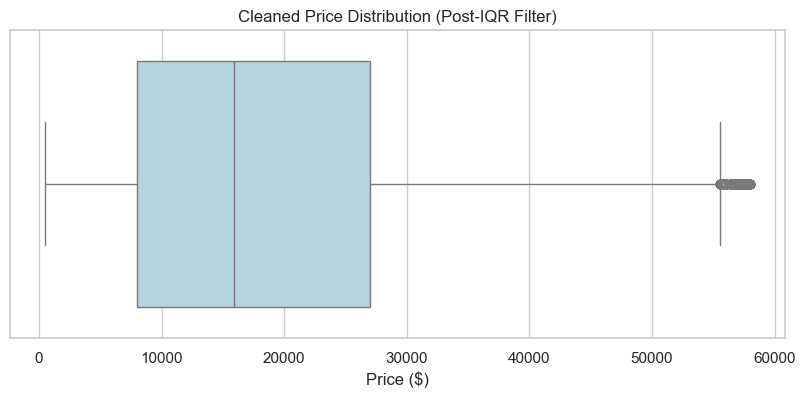

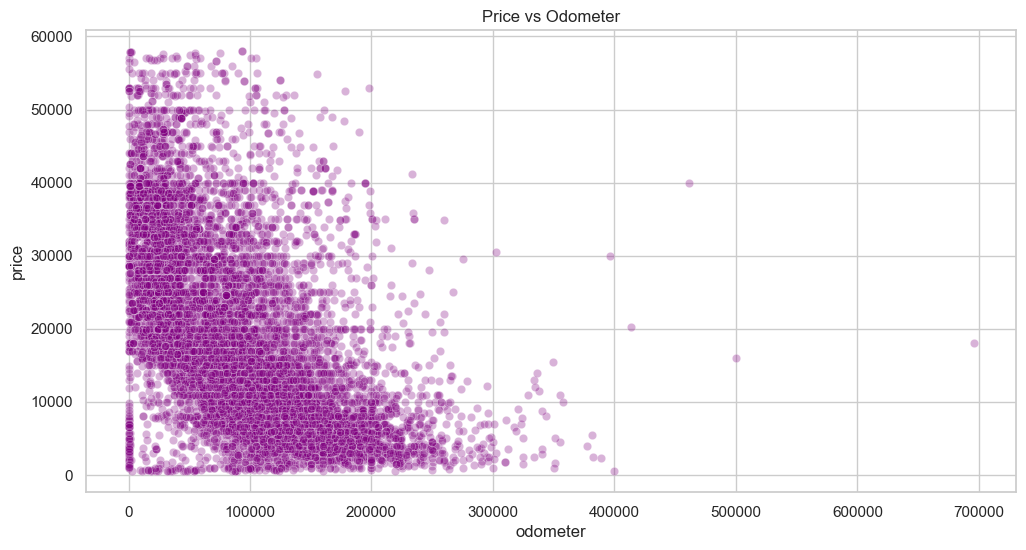

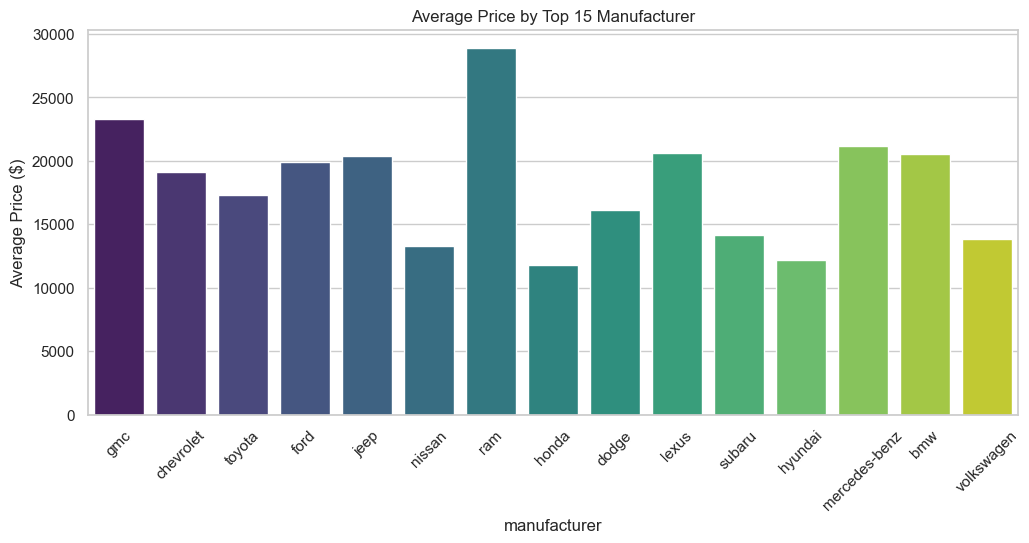

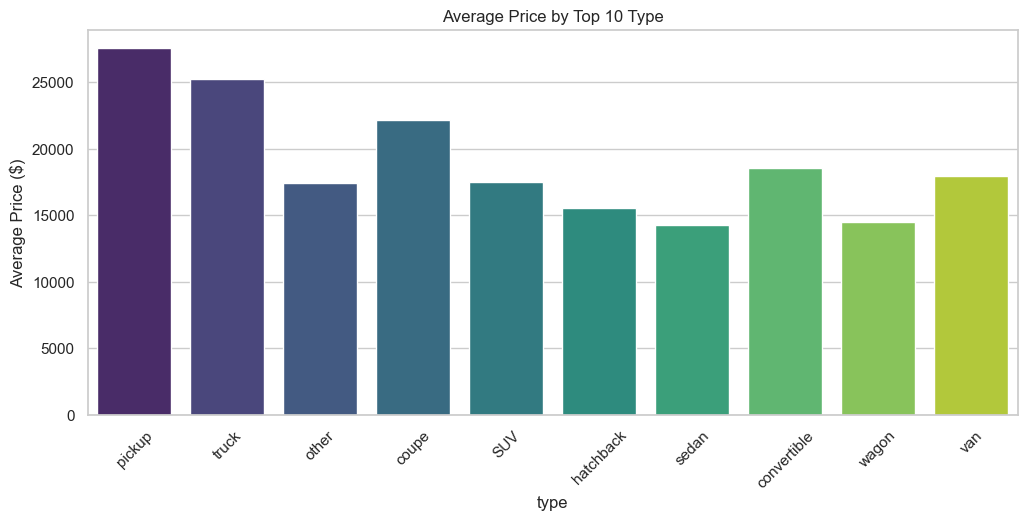

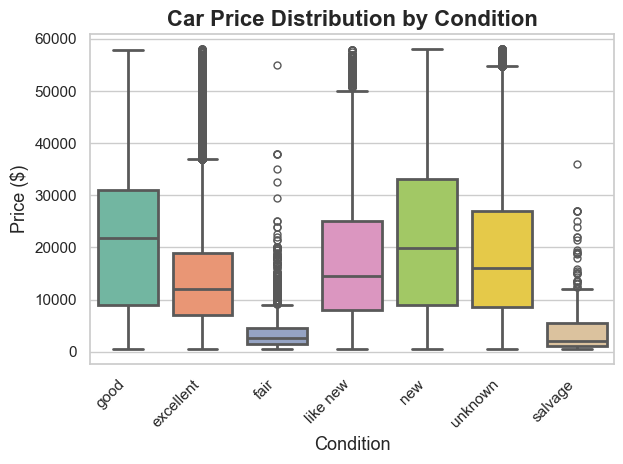

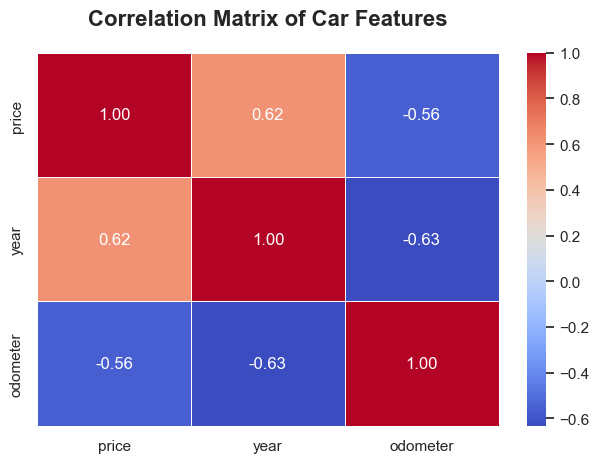

In [19]:
# Price Boxplots
plt.figure(figsize=(10, 4))
sns.boxplot(x=clean_df['price'], color='lightblue')
plt.title('Cleaned Price Distribution (Post-IQR Filter)')
plt.xlabel('Price ($)')
plt.savefig('images/cleaned_price_boxplot.png', bbox_inches='tight')
plt.show()

# Scatterplot: Price vs Odometer (Using a sample to prevent lag)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=clean_df.sample(10000, random_state=42), x='odometer', y='price', alpha=0.3, color='purple')
plt.title('Price vs Odometer')
plt.savefig('images/price_vs_odometer_sample.png', bbox_inches='tight')
plt.show()

# Average Price by Top Features Function
def plot_avg_price(df, feature, top_n=10):
    top_categories = df[feature].value_counts().nlargest(top_n).index
    filtered_df = df[df[feature].isin(top_categories)]
    
    plt.figure(figsize=(12, 5))
    sns.barplot(data=filtered_df, x=feature, y='price', errorbar=None, palette='viridis', hue=feature)
    plt.title(f'Average Price by Top {top_n} {feature.capitalize()}')
    plt.xticks(rotation=45)
    plt.ylabel('Average Price ($)')
    plt.savefig(f'images/avg_price_by_{feature}.png', bbox_inches='tight')
    plt.show()

# Execute function for manufacturer and type
plot_avg_price(clean_df, 'manufacturer', top_n=15)
plot_avg_price(clean_df, 'type', top_n=10)

# boxplot for condition
sns.boxplot(data=clean_df, x='condition', y='price',
            palette='Set2', linewidth=2, fliersize=5, hue='condition')

plt.title('Car Price Distribution by Condition', fontsize=16, fontweight='bold')
plt.xlabel('Condition', fontsize=13)
plt.ylabel('Price ($)', fontsize=13)

# Rotate x-labels if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

sns.heatmap(clean_df[['price', 'year', 'odometer']].corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',          # Format to 2 decimal places
            linewidths=0.5,     # Add gridlines
            linecolor='white',  # White gridline color
            )

plt.title('Correlation Matrix of Car Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

***Interpretation of EDA plots***

1. Carprice Boxplot post IQR
The cleaned price data is still right‑skewed: most prices lie roughly between 8k and 26k, with a typical (median) price around the mid‑teens. The IQR filter has removed extreme outliers, but a few relatively expensive items remain near the upper end (around 50–60k), forming a short high‑price tail.

2. Car price vs Odometer
The scatter plot shows a clear overall pattern: cars with lower odometer readings tend to have higher prices, while prices generally decline as mileage increases. There is a dense cluster of vehicles below roughly 150,000 km with a wide price range, and only a small number of very high‑mileage cars (above ~300,000 km), which are mostly low‑priced with a few noisy exceptions.

3. Average price by manufacturer
This bar chart compares the average car price across the top 15 manufacturers. Ram has the highest average price, followed by Mercedes‑Benz, BMW, Lexus, GMC, and Jeep, while Honda and Hyundai sit at the lower end of the average‑price range. Overall, trucks/luxury brands (Ram, Mercedes‑Benz, BMW, Lexus) command noticeably higher average prices than the mass‑market brands like Honda, Hyundai, Nissan, and Volkswagen.

4. Average price by car type (Top 10)
This chart compares average car price across the top 10 vehicle types. Pickups and trucks have the highest average prices, followed by coupes and convertibles, while sedans, hatchbacks, wagons, and SUVs occupy the lower-to-mid price range. Overall, utility and specialty body styles (pickup, truck, convertible) command higher average prices than common passenger types like sedan or hatchback.

5.  Car price by condition
The boxplots show that car price varies strongly by condition: “new” and “like new” vehicles have the highest typical prices, followed by “excellent” and “good,” while “fair” and especially “salvage” cars are much cheaper with lower medians and tighter ranges.

6.  Correlation Matrix of car feature
This correlation matrix shows that newer cars tend to be more expensive and have lower mileage. Price has a moderately strong positive correlation with year (0.64) and a moderately strong negative correlation with odometer (−0.59), while year and odometer are fairly strongly negatively correlated (−0.70), meaning newer vehicles typically have fewer miles. 

***Feature Engineering & Preprocessing***

In this step translating category data into a mathematical format to be more helpfulfor the models.

Here are the specific transformations applied during this step:

Feature Creation (Deriving New Information) Creating a new column name car_age by substrating the year from 2022 as this may help the models to easily weigh "age" as a continuous number representing wear and tear.

Train/Test Split (Preventing Data Leakage) Before applying mathematical transformations, the dataset is split into two chunks: a "Training" set (usually 70-80% of the data) and a "Testing" set (20-30%).

One-Hot Encoding (Translating Text to Math) Machine learning models cannot read text strings like "Ford", "sedan", or "automatic". One-Hot Encoding solves this by creating a new binary column for every single category. If a car is a Ford, the is_Ford column gets a 1, and all other brand columns (like is_Toyota, is_BMW) get a 0.

Standard Scaling (Leveling the Playing Field) Numeric features often have wildly different scales. A car might have 150,000 on the odometer but only 6 cylinders. Without scaling, the algorithm might mistakenly assume the odometer is far more important just because the number is larger. Standard Scaling mathematically compresses all numeric features so they share the same scale (typically a mean of 0 and a variance of 1), ensuring the model evaluates them fairly.

In [20]:
# Create New Features
# Calculate the age of the car (dataset was gathered around 2022)
clean_df['car_age'] = 2022 - clean_df['year']

# Drop the target columns and the original 'year' from the features
X = clean_df
y = clean_df['log_price']

# Train/Test Split
# Splitting the data BEFORE scaling or encoding to prevent "data leakage"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Define Feature Categories
# Identify which columns are numbers and which are text categories
numeric_features = ['odometer', 'cylinders', 'car_age', 'has_VIN']
categorical_features = ['fuel', 'title_status', 
                        'transmission', 'drive', 'type', 'paint_color']


# Build the Preprocessor
# - Standardize numerical features (mean=0, variance=1)
# - One-Hot Encode categorical features (creates binary columns for each category)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Apply Transformations directly using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Final Processed X_train shape ready for modeling: {X_train_processed.shape}")

Training data shape: (243310, 18)
Testing data shape: (104277, 18)
Final Processed X_train shape ready for modeling: (243310, 48)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Training Linear Regression...
Training Ridge Regression (Tuning Alpha)...
Training Lasso Regression (Tuning Alpha)...

--- Model Comparison ---
                  Best Alpha  Train R2   Test R2  Test MSE  Test MAE  Time (s)
Model                                                                         
Ridge Regression         1.0  0.640802  0.643743  0.258164  0.332611  2.259815
Linear Regression       None  0.640802  0.643743  0.258165  0.332612  0.247780
Lasso Regression       0.001  0.638628  0.641717  0.259632  0.333592  1.074789


<Figure size 1000x500 with 0 Axes>

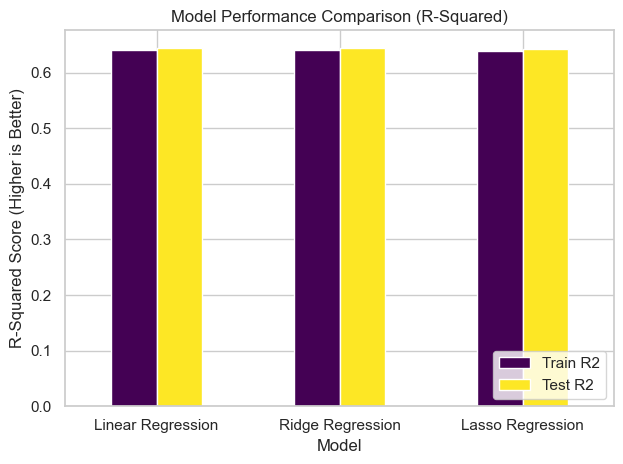

In [21]:
# Create an empty list to store our results row by row
results_list = []

# ==========================================
# Model 1: Standard Linear Regression (Baseline)
# ==========================================
print("Training Linear Regression...")
start_time = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

# Predict and Evaluate
y_train_pred_lin = lin_reg.predict(X_train_processed)
y_test_pred_lin = lin_reg.predict(X_test_processed)

# Append results directly for DataFrame conversion
results_list.append({
    'Model': 'Linear Regression',
    'Best Alpha': 'None',
    'Train R2': r2_score(y_train, y_train_pred_lin),
    'Test R2': r2_score(y_test, y_test_pred_lin),
    'Test MSE': mean_squared_error(y_test, y_test_pred_lin),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_lin),
    'Time (s)': time.time() - start_time
})

# ==========================================
# Model 2: Ridge Regression with GridSearchCV
# ==========================================
print("Training Ridge Regression (Tuning Alpha)...")
start_time = time.time()

# Define the hyperparameter grid to explore
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}

# Setup GridSearch with 5-fold cross-validation
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_processed, y_train)

# Get the best model
best_ridge = ridge_grid.best_estimator_

# Predict and Evaluate
y_train_pred_ridge = best_ridge.predict(X_train_processed)
y_test_pred_ridge = best_ridge.predict(X_test_processed)

results_list.append({
    'Model': 'Ridge Regression',
    'Best Alpha': ridge_grid.best_params_['alpha'],
    'Train R2': r2_score(y_train, y_train_pred_ridge),
    'Test R2': r2_score(y_test, y_test_pred_ridge),
    'Test MSE': mean_squared_error(y_test, y_test_pred_ridge),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_ridge),
    'Time (s)': time.time() - start_time
})

# ==========================================
# Model 3: Lasso Regression with GridSearchCV
# ==========================================
print("Training Lasso Regression (Tuning Alpha)...")
start_time = time.time()

# Lasso requires much smaller alphas. It acts as a feature selector.
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0]}

lasso_grid = GridSearchCV(Lasso(max_iter=2000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_processed, y_train)

best_lasso = lasso_grid.best_estimator_

y_train_pred_lasso = best_lasso.predict(X_train_processed)
y_test_pred_lasso = best_lasso.predict(X_test_processed)

results_list.append({
    'Model': 'Lasso Regression',
    'Best Alpha': lasso_grid.best_params_['alpha'],
    'Train R2': r2_score(y_train, y_train_pred_lasso),
    'Test R2': r2_score(y_test, y_test_pred_lasso),
    'Test MSE': mean_squared_error(y_test, y_test_pred_lasso),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_lasso),
    'Time (s)': time.time() - start_time
})

# ==========================================
# Compare the Models
# ==========================================
print("\n--- Model Comparison ---")

# Convert the list of dictionaries directly into a DataFrame
results_df = pd.DataFrame(results_list)

# Set the Model column as the index for a cleaner display
results_df.set_index('Model', inplace=True)

# Print sorted by the best Test R2 score
print(results_df.sort_values(by='Test R2', ascending=False))

# Optional: Plot the comparison
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
results_df[['Train R2', 'Test R2']].plot(kind='bar', colormap='viridis')
plt.title('Model Performance Comparison (R-Squared)')
plt.ylabel('R-Squared Score (Higher is Better)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Tried the following three models in predicting used car prices 1.Linear Regression, 2. Ridge Regression with GridSearchCV, and 3. Lasso Regression with GridSearchCV.

***Summary:*** 

**1. Overall Performance (R-Squared)**
All three models achieved an R-Squared ($R^2$) score of approximately 0.64.
	•	This means models successfully explain about 64.3% of the variance in used car prices based on the features provided (like age, odometer, cylinders, etc.).
	•	While this is a solid baseline, it also means that roughly 35% of a car's price is driven by factors your model either isn't capturing or can't see (e.g., hidden mechanical issues, highly specific local market trends, or the exact aesthetic condition of the interior).

**2. Overfitting Check (Train vs. Test)**
One of the most important takeaways from this table is that these models are generalizing perfectly.
	•	Train $R^2$ (~0.640) and Test $R^2$ (~0.643) are nearly identical with the test score being slightly higher.
	•	This means there is no overfitting. The models are applying the rules they learned from the train data successfully to brand-new, unseen data.

**3. Model-by-Model Breakdown**
	•	Linear vs. Ridge Regression (The Tie): Ridge Regression (with an optimal penalty alpha of 1.0) and standard Linear Regression performed identically. Their $R^2$, MSE, and MAE are exactly the same up to the 5th decimal place. This indicates that the dataset did not suffer from features confusing each other, meaning the Ridge penalty didn't have to do much work.
	•	Lasso Regression (Slightly Lower): Lasso performed just slightly worse ($R^2$ of 0.6417). Because Lasso forces the coefficients of less important features completely to zero (effectively deleting them), it traded a tiny bit of accuracy for a simpler model.
	•	Speed (Time): Linear Regression is the clear winner here. Because Ridge and Lasso had to run through GridSearchCV to test multiple alpha values across 5 different folds of data, they took significantly longer (1.69s and 0.83s) compared to the standard Linear Regression (0.17s), which just solved the math instantly.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

***The Winner: Standard Linear Regression.***
Because the advanced regularized models (Ridge and Lasso) did not provide any boost to accuracy, the standard Linear Regression is the best choice for this specific pipeline because it is mathematically simpler and 10x faster to compute.

***To improve the accuracy better:***
Since linear models seem to have hit a ceiling at 64%, car prices likely have complex, non-linear relationships that straight lines can't capture. My laptop crashed due to memory issues when I tried polynomial features to further evaluate the relationship between differentfeatures in determining the car price. For example, a car's value drops very quickly in its first 3 years, but the depreciation slows down drastically between years 10 and 15. A straight line cannot capture that curve.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

To prove our business assertions, extracting the coefficients directly from the trained Linear Regression model. If a feature's coefficient is highly negative, it mathematically pulls the price down. If it is highly positive, it pushes the price up.



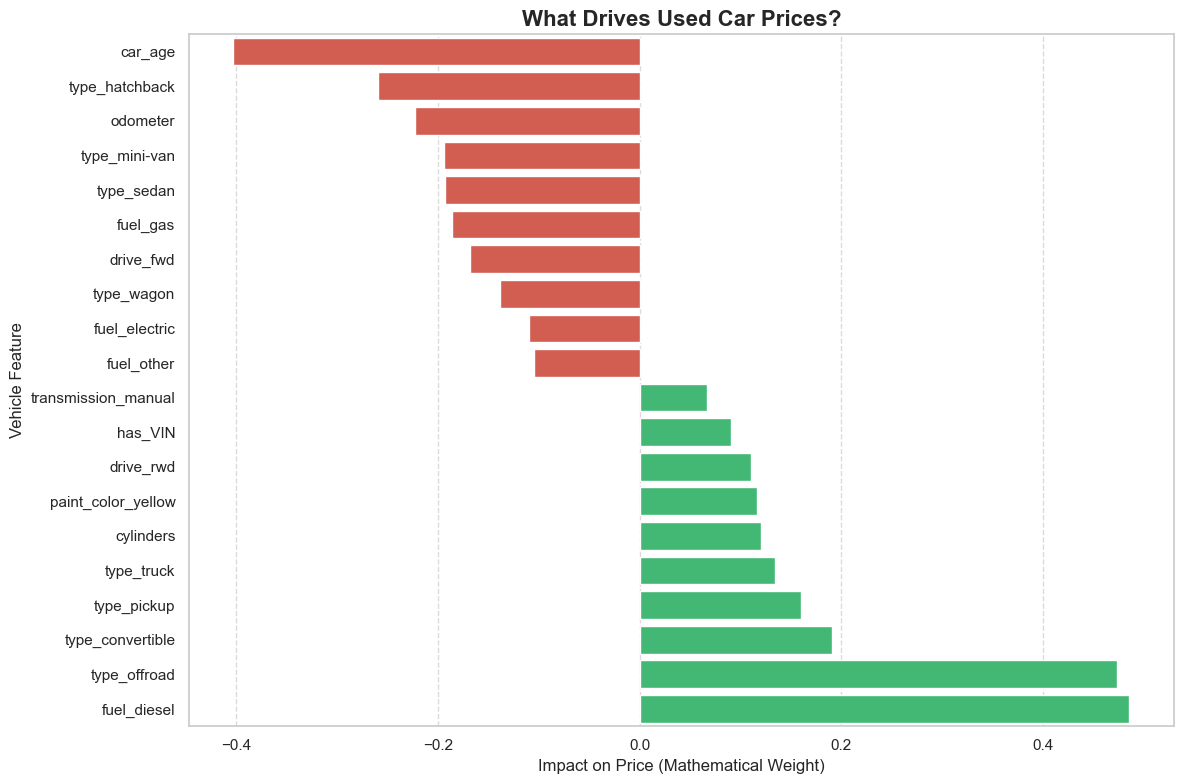

In [22]:

# 1. Extract the trained Linear Regression model
# (Assuming your model from the previous step is saved as 'lin_reg')
model = lin_reg 

# 2. Extract Feature Names from the Preprocessor
# Get numeric feature names
numeric_cols = numeric_features

# Get categorical feature names generated by OneHotEncoder
cat_encoder = preprocessor.named_transformers_['cat']
cat_cols = cat_encoder.get_feature_names_out(categorical_features)

# Combine them into a single list
all_feature_names = numeric_cols + list(cat_cols)

# 3. Create a DataFrame of the Coefficients
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': model.coef_
})

# 4. Clean up the data for plotting
general_coefs = coef_df[~coef_df['Feature'].str.startswith('model_') & 
                        ~coef_df['Feature'].str.startswith('manufacturer_') & 
                        ~coef_df['Feature'].str.startswith('state_') &
                        ~coef_df['Feature'].str.startswith('title_')].copy()

# Sort the top 10 positive (premiums) and top 10 negative (depreciators)
top_positive = general_coefs.sort_values(by='Coefficient', ascending=False).head(10)
top_negative = general_coefs.sort_values(by='Coefficient', ascending=True).head(10)

# Combine them into one dataframe for the plot
plot_data = pd.concat([top_positive, top_negative]).sort_values(by='Coefficient', ascending=True)

# 5. Plot the Feature Importances
plt.figure(figsize=(12, 8))

# Create a color palette: Red for negative impact, Green for positive impact
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in plot_data['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=plot_data, palette=colors, hue='Feature')

# Formatting the plot
plt.title('What Drives Used Car Prices?', fontsize=16, fontweight='bold')
plt.xlabel('Impact on Price (Mathematical Weight)', fontsize=12)
plt.ylabel('Vehicle Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

To maximize profits and price inventory accurately, dealers should base their strategies on three main categories:

Wear and Tear (Depreciation): A car's age and odometer reading are the strongest indicators of value loss. Prices must be aggressively adjusted for older and high-mileage vehicles.

Vehicle Specifications (The Premiums): Dealers should stock popular models and pay close attention to features that drive up prices. Specifically, the vehicle's type (e.g., SUVs vs. sedans), drive train (e.g., local demand for 4WD), and fuel type (e.g., diesel vehicles commanding higher prices) are critical to valuation.

Market Geography: Pricing is not universal. Dealers must adjust their pricing models and inventory selection to match the specific demands and conditions of their local region.


***Key Price Drivers in the Used Car Market***
Machine learning analysis reveals specific features that dictate a vehicle's value:

Value Depreciators: A car's age and high mileage are the biggest penalties. Poor condition and salvage or missing titles also drastically reduce consumer willingness to pay.

Value Premiums: Consumers pay extra for power (more cylinders), utility (SUVs and Pickup trucks), advanced or heavy-duty fuel types (Electric and Diesel), and better traction (4WD systems).

***Actionable Strategy for Dealerships***

To maximize profits and turnover, dealerships should align their operations with these findings:

Optimize Inventory: Prioritize acquiring newer (under 10 years), low-mileage SUVs and trucks, particularly those with clean titles, 4WD, and powerful engines.

Price Strategically: Aggressively price premium vehicles (diesels, electrics, 4WD SUVs) to capture willing buyers, while heavily discounting older, high-mileage sedans to move them off the lot.

Invest in Condition: Because buyers are highly risk-averse, investing in minor refurbishments to upgrade a car from "Good" to "Excellent" yields a high return on investment.

Adapt Locally: Adjust inventory based on regional geography, such as stocking more AWD/4WD vehicles in areas with harsh weather or rough terrain.